In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

In [19]:


conn = sqlite3.connect("japan_analyzer.db")
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS jobs")
cursor.execute("DROP TABLE IF EXISTS cost_of_living")

conn.commit()

print("Database reset complete")

Database reset complete


In [20]:

cursor.execute("""
CREATE TABLE jobs (
    id INTEGER PRIMARY KEY,
    title TEXT,
    company TEXT,
    city TEXT,
    salary_min INTEGER,
    salary_max INTEGER
)
""")

cursor.execute("""
CREATE TABLE cost_of_living (
    city TEXT PRIMARY KEY,
    rent INTEGER,
    food INTEGER,
    transport INTEGER,
    total_monthly_cost INTEGER
)
""")

conn.commit()

print("Tables created")

Tables created


In [21]:

jobs_data = [
    ("Software Engineer", "Mercari", "Tokyo", 60000, 120000),
    ("Data Analyst", "PayPay", "Tokyo", 50000, 90000),
    ("Software Engineer", "Rakuten", "Osaka", 45000, 85000),
]

cursor.executemany("""
INSERT INTO jobs (title, company, city, salary_min, salary_max)
VALUES (?, ?, ?, ?, ?)
""", jobs_data)

conn.commit()

print("Jobs inserted")

Jobs inserted


In [22]:
col_data = [
    ("Tokyo", 1200, 400, 150, 1750),
    ("Osaka", 900, 350, 120, 1370),
    ("Fukuoka", 700, 300, 100, 1100),
]

cursor.executemany("""
INSERT INTO cost_of_living (city, rent, food, transport, total_monthly_cost)
VALUES (?, ?, ?, ?, ?)
""", col_data)

conn.commit()

print("Cost of living inserted")

Cost of living inserted


In [23]:

jobs = pd.read_sql("SELECT * FROM jobs", conn)
col = pd.read_sql("SELECT * FROM cost_of_living", conn)

jobs, col

(   id              title  company   city  salary_min  salary_max
 0   1  Software Engineer  Mercari  Tokyo       60000      120000
 1   2       Data Analyst   PayPay  Tokyo       50000       90000
 2   3  Software Engineer  Rakuten  Osaka       45000       85000,
       city  rent  food  transport  total_monthly_cost
 0    Tokyo  1200   400        150                1750
 1    Osaka   900   350        120                1370
 2  Fukuoka   700   300        100                1100)

In [24]:
analysis = jobs.merge(col, on="city")

analysis["avg_salary"] = (analysis["salary_min"] + analysis["salary_max"]) / 2
analysis["monthly_income"] = analysis["avg_salary"] / 12
analysis["savings_potential"] = analysis["monthly_income"] - analysis["total_monthly_cost"]
analysis["savings_ratio"] = analysis["savings_potential"] / analysis["monthly_income"]
analysis.sort_values("savings_ratio", ascending=False)
analysis

,id,title,company,city,salary_min,salary_max,rent,food,transport,total_monthly_cost,avg_salary,monthly_income,savings_potential,savings_ratio
0,1,Software Engineer,Mercari,Tokyo,60000,120000,1200,400,150,1750,90000.0,7500.000000,5750.000000,0.766667
1,2,Data Analyst,PayPay,Tokyo,50000,90000,1200,400,150,1750,70000.0,5833.333333,4083.333333,0.700000
2,3,Software Engineer,Rakuten,Osaka,45000,85000,900,350,120,1370,65000.0,5416.666667,4046.666667,0.747077


In [25]:
#city comparison tool
def compare_city(city):
    return analysis[analysis["city"] == city][
        ["title", "company", "city", "monthly_income", "total_monthly_cost", "savings_potential"]
    ]

compare_city("Tokyo")

,title,company,city,monthly_income,total_monthly_cost,savings_potential
0,Software Engineer,Mercari,Tokyo,7500.000000,1750,5750.000000
1,Data Analyst,PayPay,Tokyo,5833.333333,1750,4083.333333


In [26]:
#final insights
best_city = city_rank.index[0]
best_value = city_rank.iloc[0]

print("Best city for savings:", best_city)
print("Estimated monthly savings:", round(best_value, 2))

Best city for savings: Tokyo
Estimated monthly savings: 4916.67


In [27]:

city_rank = analysis.groupby("city")["savings_potential"].mean().sort_values(ascending=False)
city_rank

,savings_potential
city,
Tokyo,4916.666667
Osaka,4046.666667


In [28]:

company_rank = analysis.groupby("company")["avg_salary"].mean().sort_values(ascending=False)
company_rank

,avg_salary
company,
Mercari,90000.0
PayPay,70000.0
Rakuten,65000.0


In [29]:

title_rank = analysis.groupby("title")["savings_potential"].mean().sort_values(ascending=False)
title_rank

,savings_potential
title,
Software Engineer,4898.333333
Data Analyst,4083.333333


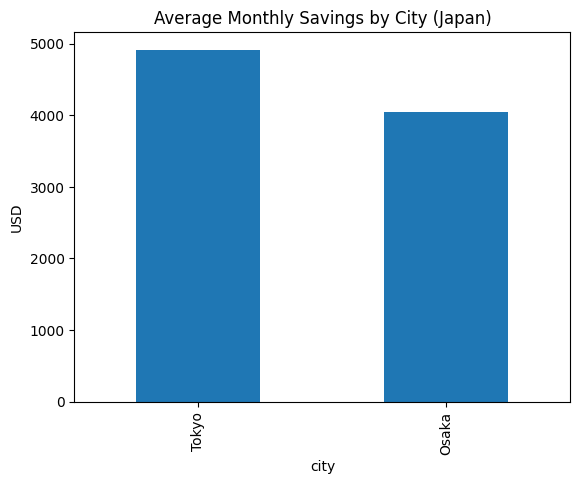

In [30]:
city_rank.plot(kind="bar")
plt.title("Average Monthly Savings by City (Japan)")
plt.ylabel("USD")
plt.show()

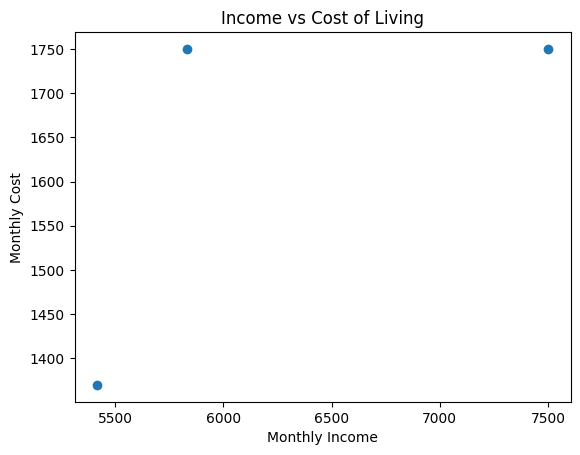

In [31]:
plt.scatter(analysis["monthly_income"], analysis["total_monthly_cost"])
plt.title("Income vs Cost of Living")
plt.xlabel("Monthly Income")
plt.ylabel("Monthly Cost")
plt.show()

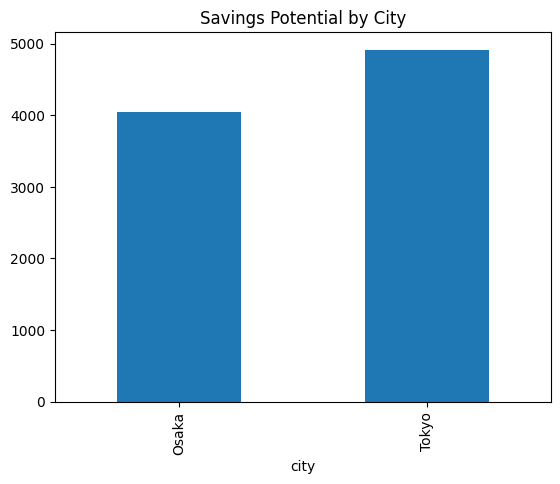

In [32]:
analysis.groupby("city")["savings_potential"].mean().plot(kind="bar")
plt.title("Savings Potential by City")
plt.show()

In [33]:
def analyze_city(city_name):
    return analysis[analysis["city"] == city_name]

analyze_city("Tokyo")

,id,title,company,city,salary_min,salary_max,rent,food,transport,total_monthly_cost,avg_salary,monthly_income,savings_potential,savings_ratio
0,1,Software Engineer,Mercari,Tokyo,60000,120000,1200,400,150,1750,90000.0,7500.000000,5750.000000,0.766667
1,2,Data Analyst,PayPay,Tokyo,50000,90000,1200,400,150,1750,70000.0,5833.333333,4083.333333,0.700000


## Key Insights

- Cities with lower cost of living increase savings significantly
- Job title matters less than location in some cases
- Salary alone is not enough to judge financial comfort in Japan

In [34]:
conn.close()

print("Connection closed safely")

Connection closed safely
